# TorchX Job Launcher

The following tutorial demonstrates how one may dispatch simulations using the [TorchX job launcher](https://meta-pytorch.org/torchx/), which `calisim` incorporates as an optional dependency.

TorchX may be used to specify and launch simulations in a distributed and parallelised fashion across different computational environments and backends (AWS, Ray, SLURM, Kubernetes). We will henceforth provide a basic example. 

In [1]:
import numpy as np
import pandas as pd
import os
import os.path as osp
import torchx

from calisim.data_model import OrchestrationModel
from calisim.orchestration import TorchXJobLauncher
from calisim.data_model import (
	DistributionModel,
	ParameterDataType,
	ParameterSpecification,
)
from calisim.abc import (
	ApproximateBayesianComputationMethod,
	ApproximateBayesianComputationMethodModel,
)
from calisim.statistics import L2Norm

import warnings
warnings.filterwarnings("ignore")

## Dispatching Python-Based Simulations

We will first define a Python command to be called externally by `TorchX`. We will later demonstrate that `calisim` is agnostic to your choice of programming language, and can be used to calibration non-Python based models - assuming that they can be called externally and supplied with parameters.

This Python command will execute the Rastrigin function, which will act as our simulation model. 

In [2]:
cmd = """
import sys
import numpy as np
import os.path as osp

def rastrigin(x, A=10):
    x = np.array(x)
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

file_name = sys.argv[1]
x1 = float(sys.argv[2])
x2 = float(sys.argv[3])
x3 = float(sys.argv[4])

x = [x1, x2, x3]

fx = rastrigin(x)
with open(osp.join('data', file_name), 'w') as f:
    f.write(str(fx))    
"""

Our implementation of Rastrigin will make use of three parameters, which are supplied as command line arguments. We next define an `OrchestrationModel` data model, which contains the parameters needed to launch the `TorchX` job. 

In [3]:
orchestration = OrchestrationModel(
    name="rastrigin",
    entrypoint="python",
    cpu=1,
    memMB=50,
    scheduler="local_cwd",
    time="00:01:59",
    wait_interval=10
)

Referring to the arguments supplied to the `OrchestrationModel` constructor, we must supply a command entrypoint, which is `python` in our case such that we can execute a Python command. We require `1 CPU`, request `50MB` of memory, dispatch the job as a local command using the `local_cwd` job scheduler, leave up to 2 minutes (`00:01:59`) to complete the job, and check on the progress of the job every `10` seconds. 

We next define the ground truth parameters for a simulation study.

In [4]:
ground_truth=dict(
    x1=0.5,
    x2=1.0,
    x3=-0.7
)

pd.DataFrame(ground_truth, index=[0])

,x1,x2,x3
0,0.5,1.0,-0.7


We'll make use of the `TorchXJobLauncher` utility class to launch a Python job with our ground truth parameteters. We'll supply an instance of the `OrchestrationModel` class, alongside command line arguments to the job launcher. These arguments must be supplied as a list.

In [5]:
runner = TorchXJobLauncher()
file_name = "ground_truth"
simulation_parameters = list(ground_truth.values())

job_results = runner.launch(
    orchestration, 
    ["-c", cmd, file_name] + simulation_parameters
)
job_results["state"]

SUCCEEDED (4)

The job appears to have succeeded. We can load and view the contents of the simulation output file like so:

In [6]:
file_path = osp.join('data', file_name)
with open(file_path, 'r') as f:
    fx = f.read()  
if os.path.exists(file_path):
    os.remove(file_path)
observed_data = np.array([float(fx)])
observed_data

array([34.83016994])

We will define a `ParameterSpecification` for the three parameters of the Rastrigin function.

In [7]:
parameter_spec = ParameterSpecification(
	parameters=[
		DistributionModel(
			name="x1",
			distribution_name="normal",
			distribution_args=[0.5, 0.05],
			data_type=ParameterDataType.CONTINUOUS,
		),
		DistributionModel(
			name="x2",
			distribution_name="normal",
			distribution_args=[1.0, 0.05],
			data_type=ParameterDataType.CONTINUOUS,
		),
		DistributionModel(
			name="x3",
			distribution_name="normal",
			distribution_args=[-0.7, 0.05],
			data_type=ParameterDataType.CONTINUOUS,
		),
	]
)

We will next define a calibration function for Appproximate Bayesian Computation.

In [8]:
def abc_func(
	parameters: dict, simulation_id: str, observed_data: np.ndarray | None
) -> float | list[float]:
    simulation_parameters = list(parameters.values())
    file_name = simulation_id
    runner.launch(
        orchestration, 
        ["-c", cmd, file_name] + simulation_parameters
    )
    
    file_path = osp.join('data', file_name)
    with open(file_path, 'r') as f:
        fx = f.read()  
    if os.path.exists(file_path):
        os.remove(file_path)
    
    simulated_data = np.array([float(fx)])
    metric = L2Norm()
    discrepancy = metric.calculate(observed_data, simulated_data)
    return discrepancy

Finally, we will perform Bayesian calibration for the Rastrigin function, demonstrating that `calisim` can incorporate `TorchX` to dispatch simulations as jobs.

ABC.Sampler INFO: Parallelize sampling on 10 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-04-12 16:05:13>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 1.56318334e+00.
ABC INFO: Accepted: 25 / 57 = 4.3860e-01, ESS: 2.5000e+01.
ABC.Adaptation INFO: Change nr particles 25 -> 10
ABC INFO: Stop: Maximum walltime.
ABC.History INFO: Done <ABCSMC id=1, duration=0:01:44.958505, end_time=2026-04-12 16:06:58>


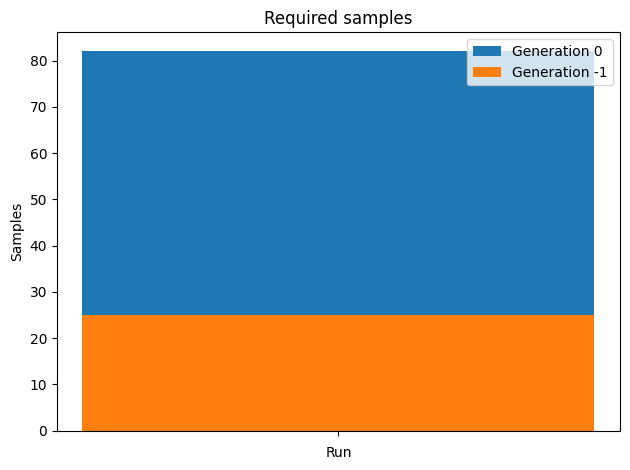

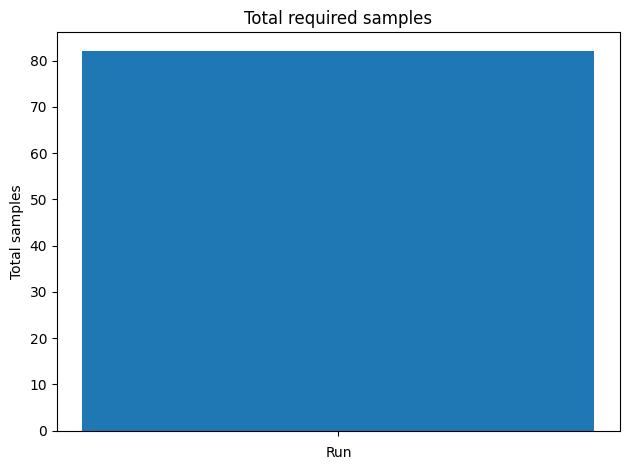

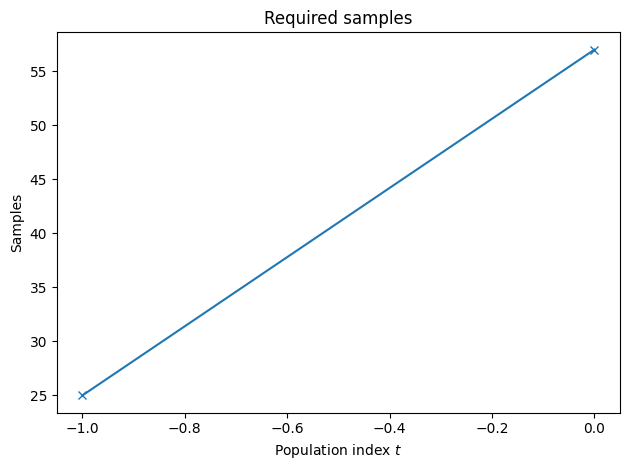

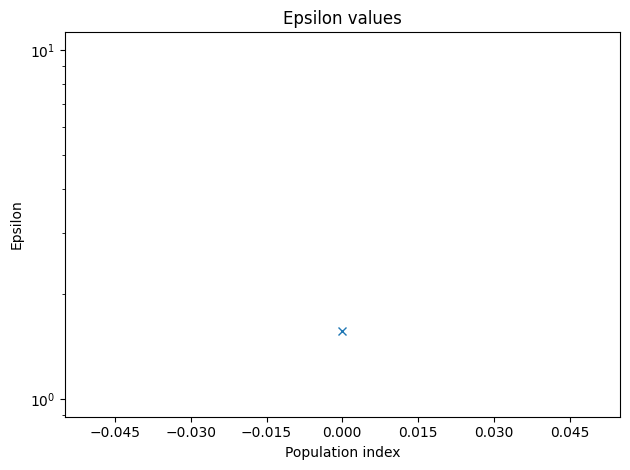

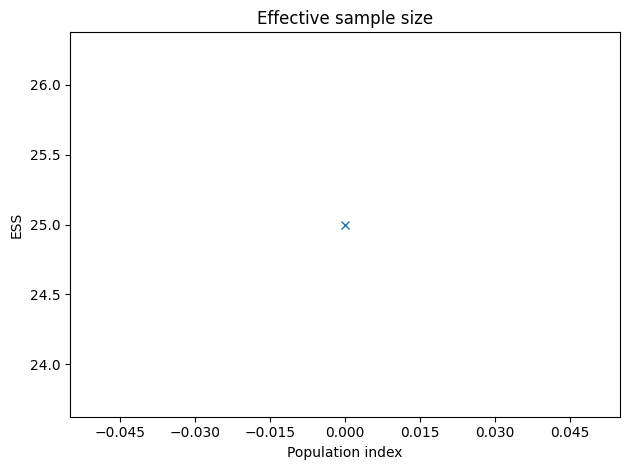

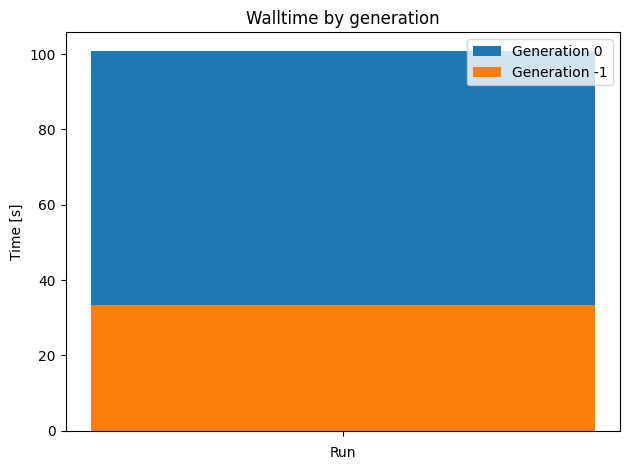

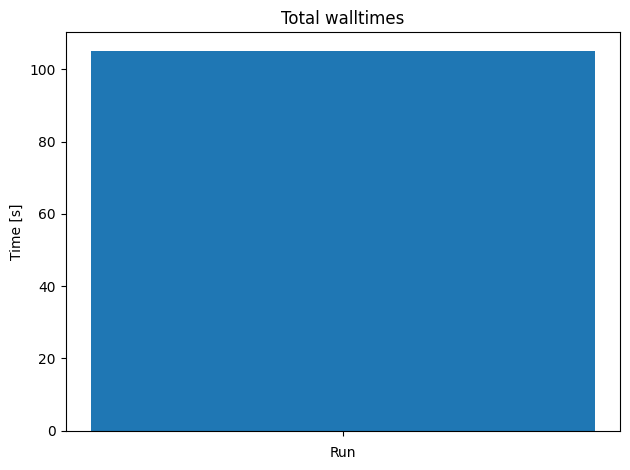

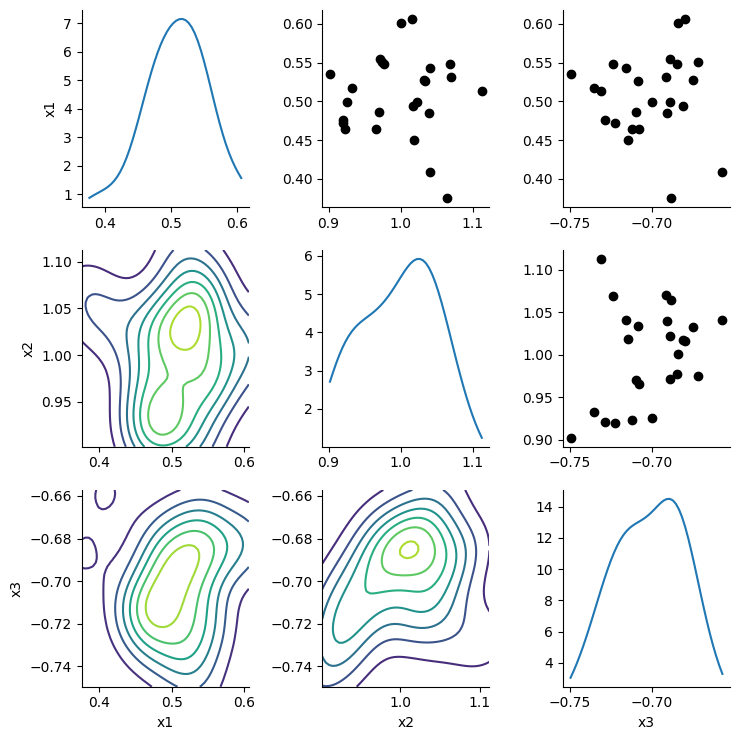

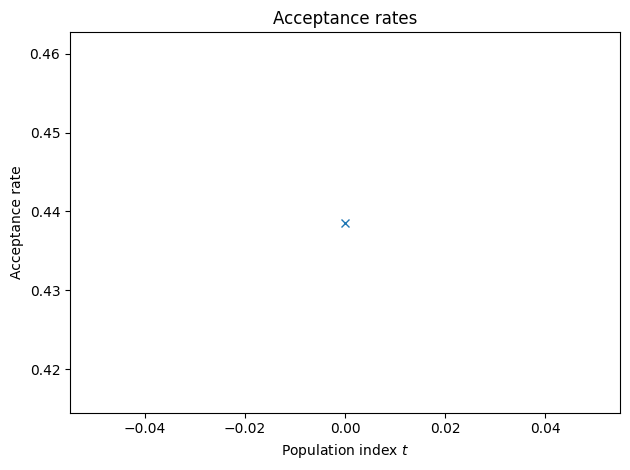

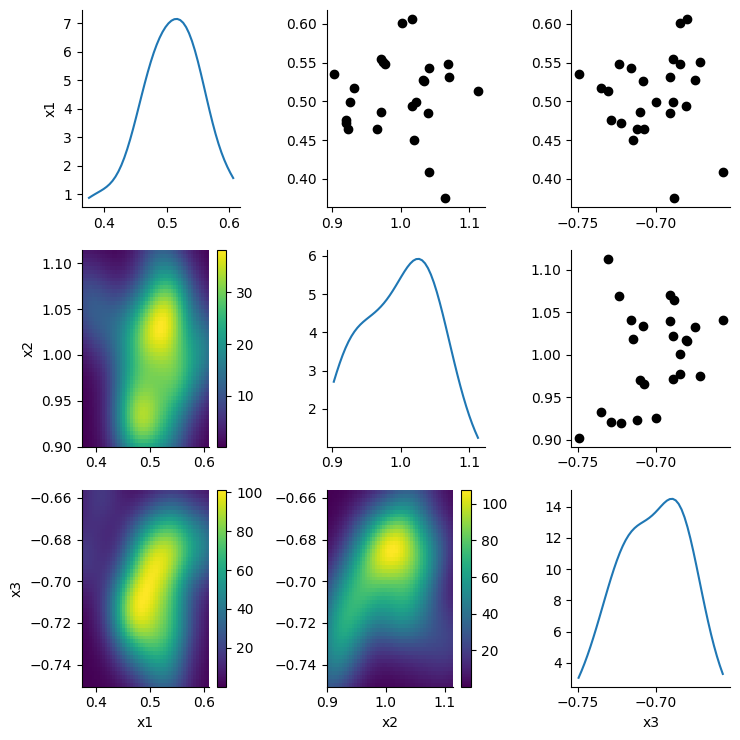

In [9]:
specification = ApproximateBayesianComputationMethodModel(
	experiment_name="pyabc_approximate_bayesian_computation",
	parameter_spec=parameter_spec,
	observed_data=observed_data,
	n_init=25,
	walltime=1,  
	epsilon=0.1,
	output_labels=["rastrigin"],
	n_bootstrap=15,
    n_jobs=10,
	min_population_size=5,
	verbose=True,
	batched=False,
	method_kwargs=dict(
		max_total_nr_simulations=100, max_nr_populations=20, min_acceptance_rate=0.0
	),
)

calibrator = ApproximateBayesianComputationMethod(
	calibration_func=abc_func, specification=specification, engine="pyabc"
)

calibrator.specify().execute().analyze()

The calibrator is able to retrieve the ground-truth parameter values from our simulation study.

In [10]:
pd.DataFrame([
    { "parameter": estimate.name, "estimate": estimate.estimate, "ground truth": ground_truth[estimate.name] }
    for estimate in calibrator.get_parameter_estimates().estimates
])

,parameter,estimate,ground truth
0,x1,0.507080,0.5
1,x2,0.998336,1.0
2,x3,-0.701737,-0.7


Overall, `TorchX` is not required for computationally light-weight functions such as our three parameter, Python-based, Rastrigin function. However, it is more useful for running non-Python simulation models which will need to be called externally, along with computationally demanding simulations that must be executed in a distributed and parallelised fashion within a computing cluster.

## Dispatching R-Based Simulations

We will next define an R script to be called externally by `TorchX`, thereby demonstrating that `calisim` is agnostic to your choice of programming language.

This R script will execute the Rastrigin function, which will act as our simulation model. 

In [11]:
cmd = """
rastrigin <- function(x, A=10) {
  n <- length(x)
  A*n + sum(x^2 - A*cos(2*pi*x))
}

args <- commandArgs(trailingOnly=TRUE)
file_name <- args[1]
x <- as.numeric(args[2:4])

out_path <- file.path("data", file_name)
fx <- rastrigin(x)
write(fx, file=out_path)
"""

r_script = "rastrigin.R"
if not os.path.exists(r_script):
    with open(r_script, 'w') as f:
        f.write(cmd)    

Our implementation of Rastrigin will make use of three parameters, which are supplied as command line arguments. We next define an `OrchestrationModel` data model, which contains the parameters needed to launch the `TorchX` job. 

In [12]:
orchestration = OrchestrationModel(
    name="rastrigin",
    entrypoint="Rscript",
    cpu=1,
    memMB=50,
    scheduler="local_cwd",
    time="00:01:59",
    wait_interval=10
)

You can see that this is nearly identical to the `OrchestrationModel` for the Python-based implementation of Rastrigin. However, note that we have changed the job entrypoint to `Rscript` as we are no longer using Python. We will run the code above using the `Rscript` command to execute an R script.

We next define the ground truth parameters for a simulation study.

In [13]:
ground_truth=dict(
    x1=0.5,
    x2=1.0,
    x3=-0.7
)

pd.DataFrame(ground_truth, index=[0])

,x1,x2,x3
0,0.5,1.0,-0.7


We'll make use of the `TorchXJobLauncher` utility class to launch an R job with our ground truth parameteters. We'll supply an instance of the `OrchestrationModel` class, alongside command line arguments to the job launcher. These arguments must be supplied as a list.

In [14]:
runner = TorchXJobLauncher()
file_name = "ground_truth"
simulation_parameters = list(ground_truth.values())

job_results = runner.launch(
    orchestration, 
    [r_script, file_name] + simulation_parameters
)
job_results["state"]

SUCCEEDED (4)

The job appears to have succeeded. We can load and view the contents of the simulation output file like so:

In [15]:
file_path = osp.join('data', file_name)
with open(file_path, 'r') as f:
    fx = f.read()  
if os.path.exists(file_path):
    os.remove(file_path)
observed_data = np.array([float(fx)])
observed_data

array([34.83017])

We will define a `ParameterSpecification` for the three parameters of the Rastrigin function.

In [16]:
parameter_spec = ParameterSpecification(
	parameters=[
		DistributionModel(
			name="x1",
			distribution_name="normal",
			distribution_args=[0.5, 0.05],
			data_type=ParameterDataType.CONTINUOUS,
		),
		DistributionModel(
			name="x2",
			distribution_name="normal",
			distribution_args=[1.0, 0.05],
			data_type=ParameterDataType.CONTINUOUS,
		),
		DistributionModel(
			name="x3",
			distribution_name="normal",
			distribution_args=[-0.7, 0.05],
			data_type=ParameterDataType.CONTINUOUS,
		),
	]
)

We will next define a calibration function for Appproximate Bayesian Computation.

In [17]:
def abc_func(
	parameters: dict, simulation_id: str, observed_data: np.ndarray | None
) -> float | list[float]:
    simulation_parameters = list(parameters.values())
    file_name = simulation_id
    job_results = runner.launch(
        orchestration, 
        [r_script, file_name] + simulation_parameters
    )
    
    file_path = osp.join('data', file_name)
    with open(file_path, 'r') as f:
        fx = f.read()  
    if os.path.exists(file_path):
        os.remove(file_path)
    
    simulated_data = np.array([float(fx)])
    metric = L2Norm()
    discrepancy = metric.calculate(observed_data, simulated_data)
    return discrepancy

Finally, we will perform Bayesian calibration for the Rastrigin function, demonstrating that `calisim` can incorporate `TorchX` to dispatch simulations as jobs.

ABC.Sampler INFO: Parallelize sampling on 10 processes.
ABC.History INFO: Start <ABCSMC id=1, start_time=2026-04-12 16:07:12>
ABC INFO: Calibration sample t = -1.
ABC INFO: t: 0, eps: 2.15310000e+00.
ABC INFO: Accepted: 25 / 54 = 4.6296e-01, ESS: 2.5000e+01.
ABC.Adaptation INFO: Change nr particles 25 -> 10
ABC INFO: Stop: Maximum walltime.
ABC.History INFO: Done <ABCSMC id=1, duration=0:01:43.556549, end_time=2026-04-12 16:08:56>


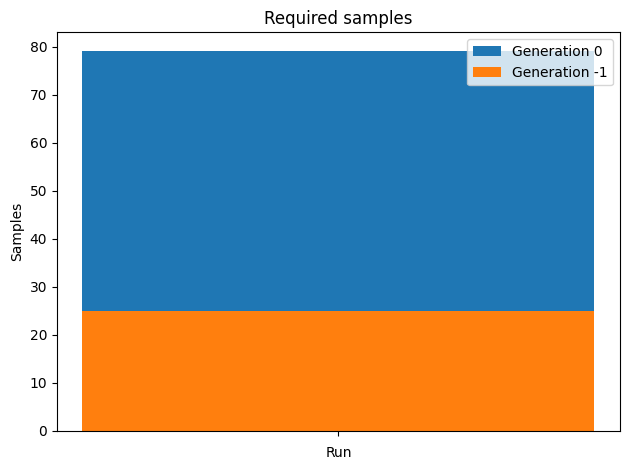

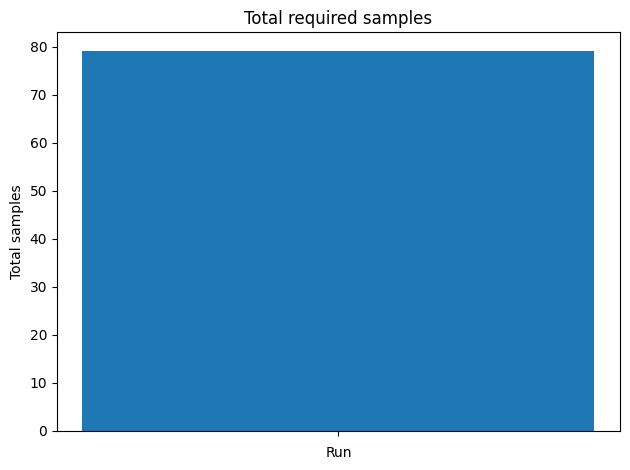

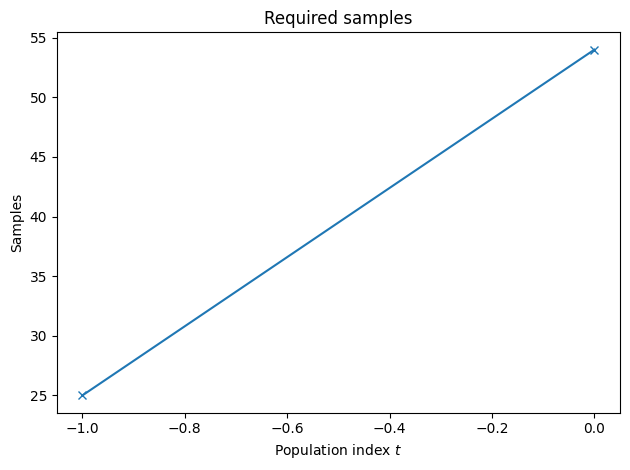

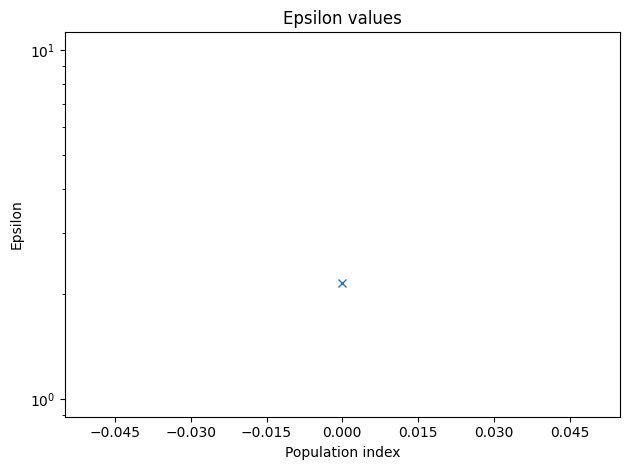

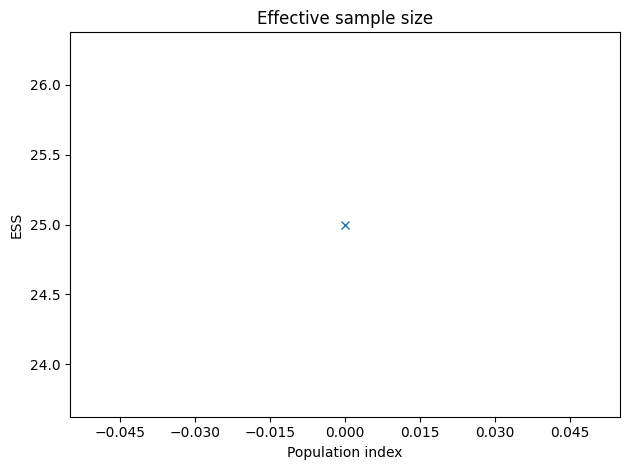

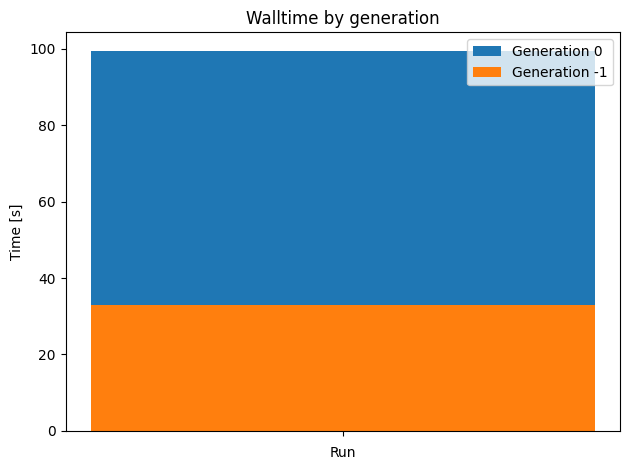

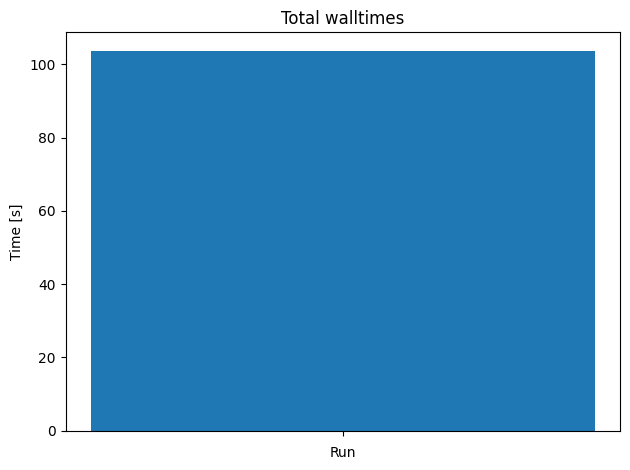

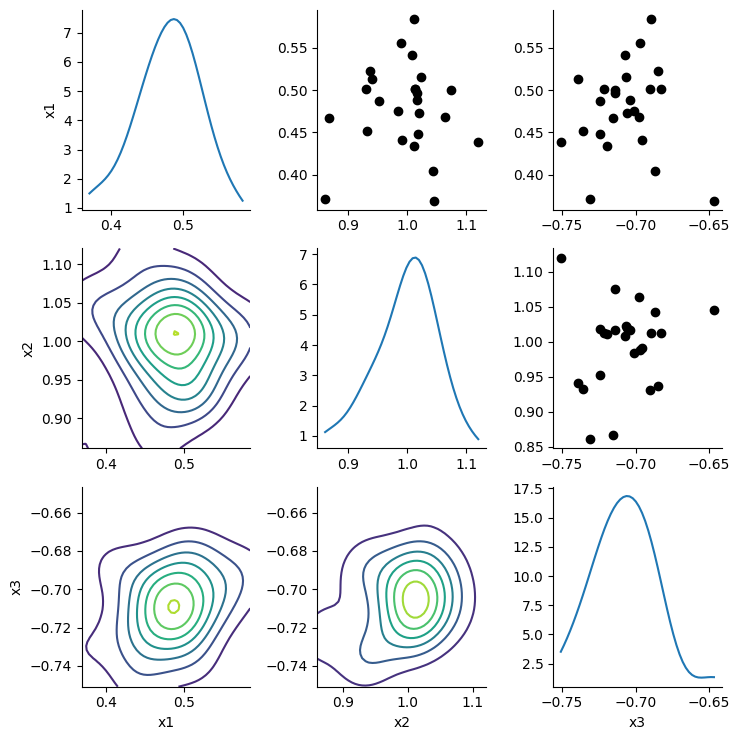

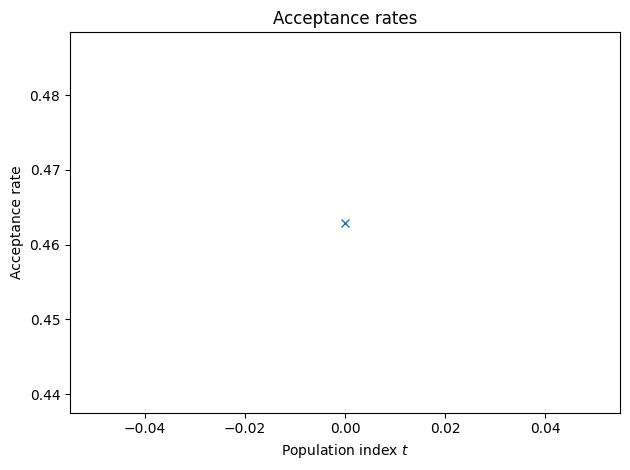

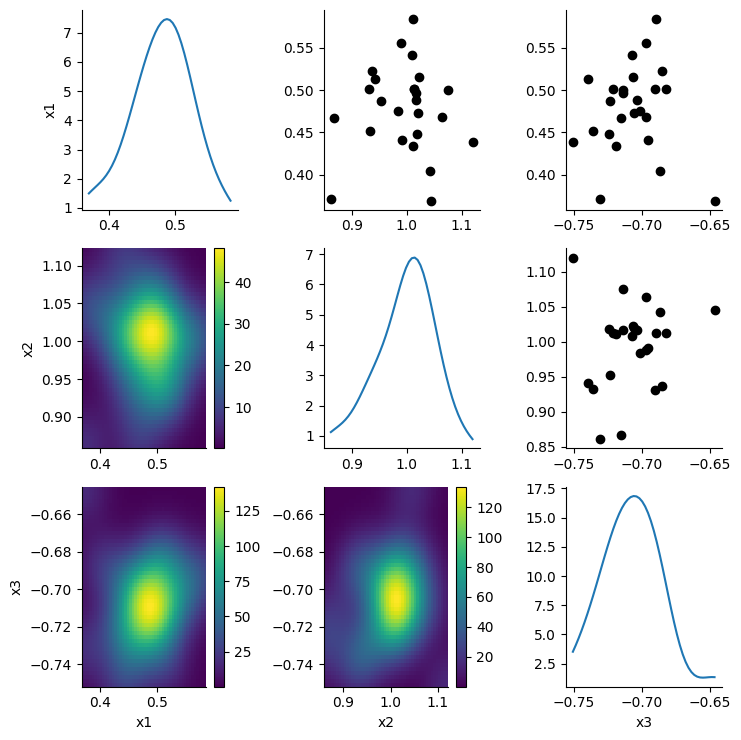

In [18]:
specification = ApproximateBayesianComputationMethodModel(
	experiment_name="pyabc_approximate_bayesian_computation",
	parameter_spec=parameter_spec,
	observed_data=observed_data,
	n_init=25,
	walltime=1,  
	epsilon=0.1,
	output_labels=["rastrigin"],
	n_bootstrap=15,
    n_jobs=10,
	min_population_size=5,
	verbose=True,
	batched=False,
	method_kwargs=dict(
		max_total_nr_simulations=100, max_nr_populations=20, min_acceptance_rate=0.0
	),
)

calibrator = ApproximateBayesianComputationMethod(
	calibration_func=abc_func, specification=specification, engine="pyabc"
)

calibrator.specify().execute().analyze()

The calibrator is able to retrieve the ground-truth parameter values from our simulation study.

In [19]:
pd.DataFrame([
    { "parameter": estimate.name, "estimate": estimate.estimate, "ground truth": ground_truth[estimate.name] }
    for estimate in calibrator.get_parameter_estimates().estimates
])

,parameter,estimate,ground truth
0,x1,0.478148,0.5
1,x2,0.995373,1.0
2,x3,-0.707393,-0.7


Overall, `TorchX` is not required for computationally light-weight functions such as our R-based, Rastrigin function. However, it is more useful for computationally demanding simulations that must be executed in a distributed and parallelised fashion within a computing cluster. 

For the examples above, we have set the `TorchX` scheduler to `local_cwd`. Hence, we are running the simulations locally. However, `TorchX` supports many different schedulers, and it's worth experimenting with them.

In [20]:
pd.DataFrame(torchx.schedulers.get_scheduler_factories().keys())

,0
0,local_docker
1,local_cwd
2,slurm
3,kubernetes
4,kubernetes_mcad
5,aws_batch
6,aws_sagemaker
7,lsf
